In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
iris_data = pd.read_csv("Iris.csv")
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
encoder = LabelEncoder()

iris_data["Species"] = encoder.fit_transform(iris_data["Species"])

In [10]:
iris_data.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
113,114,5.7,2.5,5.0,2.0,2
140,141,6.7,3.1,5.6,2.4,2
9,10,4.9,3.1,1.5,0.1,0
86,87,6.7,3.1,4.7,1.5,1
18,19,5.7,3.8,1.7,0.3,0
97,98,6.2,2.9,4.3,1.3,1
24,25,4.8,3.4,1.9,0.2,0
11,12,4.8,3.4,1.6,0.2,0
82,83,5.8,2.7,3.9,1.2,1
61,62,5.9,3.0,4.2,1.5,1


In [11]:
iris_data = iris_data[['SepalLengthCm', 'PetalLengthCm', 'Species']]
iris_data

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [13]:
X = iris_data.drop("Species", axis=1)
y = iris_data["Species"]

In [15]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(multi_class='multinomial')
model.fit(X_train, y_train)

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [17]:
y_pred = model.predict(X_test)

In [18]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [19]:
print(accuracy_score(y_test, y_pred))

1.0


In [20]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,10,0,0
1,0,9,0
2,0,0,11


In [22]:
#prediction

query = np.array([[3.2, 2.7]])
model.predict_proba(query)

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[8.32395978e-01, 1.66986650e-01, 6.17371790e-04]])

In [23]:
model.predict(query)

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


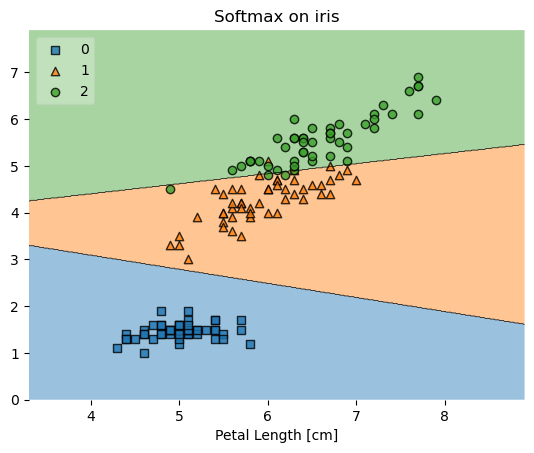

In [24]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions (X.values, y.values, model, legend=2)

plt.xlabel('Sepal Length [cm]')
plt.xlabel('Petal Length [cm]')
plt.title("Softmax on iris")

plt.show()